# 4-2 : ピーク検出、全20天体解析
## プロット出力+結果一覧表作成

# Done
## Fig 5. SED 
SED example
Mrk421 MJD59120 & PKS0426-380 MJD57552
Fig, 5 - like, everything: font sizes, labels; what is phi? Connections of the points; and probably even the choice of which plots to show here. Likely better to sit on it together.

# --- TO DO ---
# --- Done ---
- フィット結果異常SEDの初期値変更再フィット
- ピーク判定改善
  - ピーク領域、全範囲判定(4点以上対応)
  - 複数ピークの可能性
- ピークの有意度：別スクリプトを作る必要がある
  - ピーク領域の同定(3点とは限らない) : (done in 7e5ab401f3a3671d2f69febeeab11c41812be7a2, "ピーク有意度計算")
- 検出ピーク率にCIを付加する 
(done in e5437013ffd869ecaa37084c0cee54b2b39f5e50, "redshift + k/N confidence interval")
- 天体クラス表記大文字に統一 
(done in 47cbabf4c7ab2945038b63a535206efc68358471, "source cls 大文字統一")





# Analyze and make a table


天体一覧の上位20天体
各天体について、
SED ecsvファイルの解析をする




## Utility
### - 天体名対応辞書作成

In [1]:
from astropy.io import fits
import numpy as np

def get_dict_sourcenames():
  num_sources = 2300
  hdu=fits.open('/Users/kazuma/Workspace/Torun/Fermi/catalog/gll_psc_v35.fit')
  significances = hdu[1].data['Signif_Avg']
  sources = hdu[1].data['Source_Name']
  sources1 = hdu[1].data['ASSOC1']
  sources2 = hdu[1].data['ASSOC2']
  sources_cls=hdu[1].data['CLASS1']
  #Convert source classes to normal array without empty spaces
  source_classes = np.array([entry.strip() for entry in hdu[1].data['CLASS1']])
  #Filter by source class:
  source_classes_selected = np.array(["bll","fsrq","BLL","FSRQ"],dtype='<U5') #see table 5 in https://arxiv.org/pdf/2201.11184
  element_map = np.isin(source_classes, source_classes_selected)
  significances_blazars= significances[element_map]
  sources_blazars = sources[element_map]
  sources_blazars1 = sources1[element_map]
  sources_blazars2 = sources2[element_map]
  sources_blazars_cls = source_classes[element_map]
  #Get index of 20 brightes sources:
  idx = (-significances_blazars).argsort()[:num_sources]
  indices = np.arange(1,num_sources+1)
  # print(f"Number of sources: {len(sources_blazars[idx])}")
  # print(f"Indices of the sources: {indices}")
  #Get the same of the 20 most significant blazars:
  # print(sources_blazars[idx])
  from astropy.table import Table
  # t = Table([sources_blazars[idx],
  #   sources_blazars1[idx],
  #   sources_blazars_cls[idx],
  #   ],names=['4FGL name','assoc name','CLASS','index'])
  

  # sources_blazars_converted  = sources_blazars.strip().replace(' ','_').lower()
  sources_blazars_converted  = sources_blazars.strip().replace('4FGL ','').lower()
  sources_blazars1_converted = sources_blazars1.strip().replace(' ','_').lower()
  sources_blazars_selected_cls = sources_blazars_cls[idx]
  # print(sources_blazars_selected_cls)
  # print(sources_blazars_cls[idx])
  # The elements of sources_blazars_selected_cls are mixture of upper/lower cases. 
  # We unify them to upper case here.
  sources_blazars_selected_cls_converted = np.array([entry.upper() for entry in sources_blazars_selected_cls])
  # print(sources_blazars_selected_cls_converted)  

#   dict_sourcenames = dict(zip(sources_blazars_converted[idx],sources_blazars1_converted[idx]))

  ref_tab_obj = Table([sources_blazars_converted[idx],
  sources_blazars1_converted[idx],
  sources_blazars_selected_cls_converted, #sources_blazars_cls[idx], 
  indices],
  names=['4FGL name','assoc name','CLASS','index'])
# ref_tab_obj[ref_tab_obj['4FGL name'] == '4fgl_j0112.1+2245']
  return ref_tab_obj


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


### 使い方

In [2]:
dict_sourcename = get_dict_sourcenames()
dict_sourcename[0:2]

4FGL name,assoc name,CLASS,index
str13,str28,str4,int64
j2253.9+1609,3c_454.3,FSRQ,1
j1104.4+3812,mkn_421,BLL,2


In [3]:
dict_sourcename[0]['assoc name']  = '3C454.3' 
dict_sourcename[1]['assoc name']  = 'Mrk421' 
dict_sourcename[2]['assoc name']  = 'BLLac' 
dict_sourcename[3]['assoc name']  = 'CTA102' 
dict_sourcename[4]['assoc name']  = '3C279'
dict_sourcename[5]['assoc name']  = 'S50716+71' 
dict_sourcename[6]['assoc name']  = 'PKS1424-41' 
dict_sourcename[7]['assoc name']  = 'PKS0426-380'
dict_sourcename[8]['assoc name']  = 'PKS0537-441'
dict_sourcename[9]['assoc name']  = 'PKS2155-304'
dict_sourcename[10]['assoc name'] = 'PKS0454-234'
dict_sourcename[11]['assoc name'] = 'PKS1510-089'
dict_sourcename[12]['assoc name'] = 'PKS1502+106'
dict_sourcename[13]['assoc name'] = 'TON599'
dict_sourcename[14]['assoc name'] = 'PKS0346-27'
dict_sourcename[15]['assoc name'] = '4c+01.02'
dict_sourcename[16]['assoc name'] = '4c+55.17'
dict_sourcename[17]['assoc name'] = '4c+21.35'
dict_sourcename[18]['assoc name'] = 'PKS1830-211'
dict_sourcename[19]['assoc name'] = 'PKS0208-512'
dict_sourcename[0:15]

4FGL name,assoc name,CLASS,index
str13,str28,str4,int64
j2253.9+1609,3C454.3,FSRQ,1
j1104.4+3812,Mrk421,BLL,2
j2202.7+4216,BLLac,BLL,3
j2232.6+1143,CTA102,FSRQ,4
j1256.1-0547,3C279,FSRQ,5
j0721.9+7120,S50716+71,BLL,6
j1427.9-4206,PKS1424-41,FSRQ,7
j0428.6-3756,PKS0426-380,BLL,8
j0538.8-4405,PKS0537-441,BLL,9


In [4]:
def update_dict_sourcenames_for_drawing(dict_sourcename):
  # add the key 'assoc name for drawing' to dict_sourcename(astropy Table), which is used for drawing the SEDs.
  dict_sourcename['assoc name for drawing'] = ["not assigned"]*len(dict_sourcename)
  dict_sourcename[ 0]['assoc name for drawing']  = '3C 454.3' 
  dict_sourcename[ 1]['assoc name for drawing']  = 'Mrk 421' 
  dict_sourcename[ 2]['assoc name for drawing']  = 'BL Lac' 
  dict_sourcename[ 3]['assoc name for drawing']  = 'CTA 102' 
  dict_sourcename[ 4]['assoc name for drawing']  = '3C 279'
  dict_sourcename[ 5]['assoc name for drawing']  = 'S5 0716+71' 
  dict_sourcename[ 6]['assoc name for drawing']  = 'PKS 1424-41' 
  dict_sourcename[ 7]['assoc name for drawing']  = 'PKS 0426-380'
  dict_sourcename[ 8]['assoc name for drawing']  = 'PKS 0537-441'
  dict_sourcename[ 9]['assoc name for drawing']  = 'PKS 2155-304'
  dict_sourcename[10]['assoc name for drawing'] = 'PKS 0454-234'
  dict_sourcename[11]['assoc name for drawing'] = 'PKS 1510-089'
  dict_sourcename[12]['assoc name for drawing'] = 'PKS 1502+106'
  dict_sourcename[13]['assoc name for drawing'] = 'TON 599'
  dict_sourcename[14]['assoc name for drawing'] = 'PKS 0346-27'
  dict_sourcename[15]['assoc name for drawing'] = '4C +01.02'
  dict_sourcename[16]['assoc name for drawing'] = '4C +55.17'
  dict_sourcename[17]['assoc name for drawing'] = '4C +21.35'
  dict_sourcename[18]['assoc name for drawing'] = 'PKS 1830-211'
  dict_sourcename[19]['assoc name for drawing'] = 'PKS 0208-512'
  dict_sourcename[0:15]
  return dict_sourcename


### 赤方偏辞書作成 (1)

https://iopscience.iop.org/0067-0049/253/2/46/suppdata/apjsabe135t9_ascii.txt?doi=10.3847/1538-4365/abe135

From the article, Paliya+21 
"The Central Engines of Fermi Blazars"
https://iopscience.iop.org/article/10.3847/1538-4365/abe135#apjsabe135t10


In [5]:

import numpy as np
from astropy.table import Table
def get_dict_redshift():
  tab = Table.read('./catalogs/apjsabe135t9_ascii_edited.txt',format='ascii')
  return tab
  

### 使い方

In [6]:
dict_redshift = get_dict_redshift()
print(dict_redshift[0:5])

 4FGL name   Redshift M_BH M_BH_error
------------ -------- ---- ----------
J0037.8+1239    0.089 8.64       0.14
J0050.7-0929    0.635 8.85       0.18
J0109.1+1815    0.145 9.09       0.23
J0123.1+3421    0.272 8.68       0.14
J0159.5+1046    0.195 8.51       0.14


In [7]:
# add redshift to dict_sourcename, searching from dict_redshift
for i in range(len(dict_sourcename)):
  source_4FGL = dict_sourcename[i]['4FGL name'].upper()
  source_assoc = dict_sourcename[i]['assoc name']
  print(f"Searching for {source_4FGL}, {source_assoc}")
  mask = (dict_redshift['4FGL name'] == source_4FGL.lower())
  print(mask)
  # if len(match) == 0:
  #   match = dict_redshift[dict_redshift['Source name'].str.strip().replace(' ','').lower() == source_assoc.replace(' ','').lower()]
  # if len(match) == 0:
  #   print(f"Not found: {source_4FGL}, {source_assoc}")
  #   dict_sourcename[i]['redshift'] = np.
  # elif len(match) > 1:
  #   print(f"Multiple matches found for {source_4FGL}, {source_assoc}:")
  #   print(match)
  #   dict_sourcename[i]['redshift'] = match[0]['Redshift']
  # else:
  #   dict_sourcename[i]['redshift'] = match[0]['Redshift']



Searching for J2253.9+1609, 3C454.3
[False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False]
Searching for J1104.4+3812, Mrk421
[False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False]
Searching for J2202.7+4216, BLLac
[False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False]
Searching for J2232.6+1143, CTA102

### 赤方偏辞書作成 (2)

https://iopscience.iop.org/1538-3881/168/6/289/suppdata/ajad8231t1_ascii.txt?doi=10.3847/1538-3881/ad8231

From article N. Sahakyan+24
"Markarian Multiwavelength Data Center (MMDC): A Tool for Retrieving and Modeling Multitemporal, Multiwavelength, and Multimessenger Data from Blazar Observations"
https://iopscience.iop.org/article/10.3847/1538-3881/ad8231


In [8]:
import numpy as np
from astropy.table import Table
def get_dict_redshift():
  tab = Table.read('./catalogs/ajad8231t1_ascii_edited.txt',delimiter=',', header_start=0,data_start=1, format='ascii')
  return tab

In [9]:
dict_redshift = get_dict_redshift()
print(dict_redshift[0:5])

Source name   4FGL name   Source Class SED Class  R.A.  Decl. Redshift col7
------------ ------------ ------------ --------- ------ ----- -------- ----
    3C 454.3 J2253.9+1609         FSRQ       LSP  343.5 16.15     0.86   --
      3C 279 J1256.1-0547         FSRQ       LSP 194.04 -5.79     0.54   --
     CTA 102 J2232.6+1143         FSRQ       LSP 338.15 11.73     1.04   --
     Mkn 421 J1104.4+3812          BLL       HSP 166.12 38.21     0.03   --
PKS 1510-089 J1512.8-0906         FSRQ       LSP 228.21 -9.11     0.36   --


In [10]:
# add redshift to dict_sourcename, searching from dict_redshift
dict_sourcename['redshift'] = np.nan
for i in range(len(dict_sourcename)):
  source_4FGL = dict_sourcename[i]['4FGL name'].upper().replace(' ','')
  source_assoc = dict_sourcename[i]['assoc name']
  # print(f"Searching for {source_4FGL}, {source_assoc}")
  mask = (dict_redshift['4FGL name'] == source_4FGL)
  # print(mask, np.sum(mask))
  if np.sum(mask) > 0:
    dict_sourcename[i]['redshift'] = dict_redshift['Redshift'][mask]

print(dict_sourcename[0:20])


 4FGL name    assoc name CLASS index redshift
------------ ----------- ----- ----- --------
j2253.9+1609     3C454.3  FSRQ     1     0.86
j1104.4+3812      Mrk421   BLL     2     0.03
j2202.7+4216       BLLac   BLL     3     0.07
j2232.6+1143      CTA102  FSRQ     4     1.04
j1256.1-0547       3C279  FSRQ     5     0.54
j0721.9+7120   S50716+71   BLL     6     0.13
j1427.9-4206  PKS1424-41  FSRQ     7     1.52
j0428.6-3756 PKS0426-380   BLL     8     1.11
j0538.8-4405 PKS0537-441   BLL     9    0.896
j2158.8-3013 PKS2155-304   BLL    10     0.12
j0457.0-2324 PKS0454-234  FSRQ    11      1.0
j1512.8-0906 PKS1510-089  FSRQ    12     0.36
j1504.4+1029 PKS1502+106  FSRQ    13     1.84
j1159.5+2914      TON599  FSRQ    14   0.7247
j0348.6-2749  PKS0346-27  FSRQ    15    0.991
j0108.6+0134    4c+01.02  FSRQ    16    2.099
j0957.6+5523    4c+55.17  FSRQ    17   0.8955
j1224.9+2122    4c+21.35  FSRQ    18     0.43
j1833.6-2103 PKS1830-211  FSRQ    19    2.507
j0210.7-5101 PKS0208-512  FSRQ    

In [11]:
print(dict_sourcename[0:20])

 4FGL name    assoc name CLASS index redshift
------------ ----------- ----- ----- --------
j2253.9+1609     3C454.3  FSRQ     1     0.86
j1104.4+3812      Mrk421   BLL     2     0.03
j2202.7+4216       BLLac   BLL     3     0.07
j2232.6+1143      CTA102  FSRQ     4     1.04
j1256.1-0547       3C279  FSRQ     5     0.54
j0721.9+7120   S50716+71   BLL     6     0.13
j1427.9-4206  PKS1424-41  FSRQ     7     1.52
j0428.6-3756 PKS0426-380   BLL     8     1.11
j0538.8-4405 PKS0537-441   BLL     9    0.896
j2158.8-3013 PKS2155-304   BLL    10     0.12
j0457.0-2324 PKS0454-234  FSRQ    11      1.0
j1512.8-0906 PKS1510-089  FSRQ    12     0.36
j1504.4+1029 PKS1502+106  FSRQ    13     1.84
j1159.5+2914      TON599  FSRQ    14   0.7247
j0348.6-2749  PKS0346-27  FSRQ    15    0.991
j0108.6+0134    4c+01.02  FSRQ    16    2.099
j0957.6+5523    4c+55.17  FSRQ    17   0.8955
j1224.9+2122    4c+21.35  FSRQ    18     0.43
j1833.6-2103 PKS1830-211  FSRQ    19    2.507
j0210.7-5101 PKS0208-512  FSRQ    


## - Utility functions


### Probability table generation

14 bins from 9 to 22


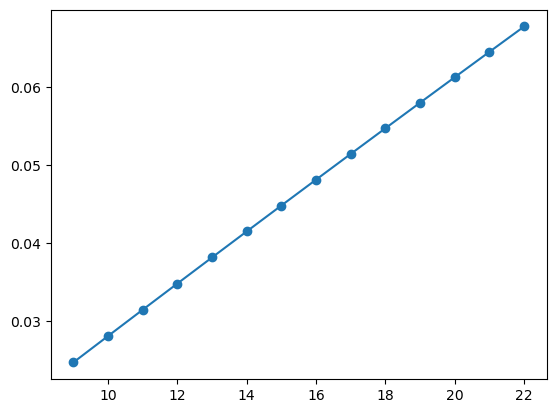

In [12]:
import numpy as np
# p=(1-0.95)/2.0
nbinsmin=9
nbinsmax=22
p=(1-0.68)/2.0
P=np.array([[1-p,p,0,0],[1-p,0,p,0],[1-p,0,0,p],[0,0,0,1]])
A=np.matrix(P)
probs = []
for ibins in range(nbinsmin, nbinsmax+1):
  B=A**ibins
  probs.append(B[0,3])

print(len(probs), "bins from", nbinsmin, "to", nbinsmax)
import matplotlib.pyplot as plt
plt.plot(range(nbinsmin, nbinsmax+1), probs, marker='o')

### Peak detection
### Gaussian
### Red.Chisq. calculation
### Confidence interval (of k/N) calculation
### plotSED

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack
from astropy.modeling.powerlaws import LogParabola1D
from astropy.modeling import models, fitting
from astropy import units as u
from scipy.optimize import curve_fit
from scipy.stats import chi2, norm

###################
# Peak detection
###################
nconsecutive = 3
def get_consecutive_bins(s,nconsecutive ):

  for i in range(0,len(s)-nconsecutive+1):
  # for i in range(0,len(s)-nconsecutive):
      if np.all(s[i:i+nconsecutive] > 1.0):
        #   print(i)
        #   print(s[i:i+nconsecutive])
        #   print('---')
          return i
      
  return -1

###################
# Peak detection, improved
###################
def get_consecutive_bins_for_multi_peaks(s,nconsecutive = 3 ):
  # from s, find all the sets of consecutive bins that have values > 1.0 for at least nconsecutive bins
  # return the list of (peakinitbin, peaklength, significance)s
  peakinitbins=[]
  peaklengths=[]
  # significances=[]
  peakinitbin = -1
  for i in range(0,len(s)-nconsecutive+1):  
    if np.all(s[i:i+nconsecutive] > 1.0):
      if peakinitbin < 0:
        peakinitbin = i
      if i + nconsecutive == len(s):
        peakinitbins.append(peakinitbin)
        peaklengths.append(i + nconsecutive - peakinitbin)
        # significances.append(calc_peak_significance(s[peakinitbin:i+nconsecutive]))
        return   peakinitbins,peaklengths#,significances
    else:
      if peakinitbin >= 0:
        peakinitbins.append(peakinitbin)
        peaklengths.append(i + nconsecutive -1 - peakinitbin)
        # significances.append(calc_peak_significance(s[peakinitbin:i+nconsecutive-1]))
        peakinitbin = -1
  return   peakinitbins,peaklengths#,significances
###################
# Utility functions
###################
def gaussian(x, amplitude, mu, sigma):
    # return (1.0 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2) : Normal distribution
    return amplitude * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def calc_reduced_chi_square(fit, x, y, yerr, N, n_free):
    '''
    fit (array) values for the fit
    x,y,yerr (arrays) data
    N total number of points
    n_free number of parameters we are fitting
    '''
    return 1.0/(N-n_free)*sum(((fit - y)/yerr)**2)




################################################
### # Confidence interval calculation - not used yet
### 
### 
### 
#################################################
from scipy.stats import beta
import numpy as np
def calc_ci_ClopperPearson(k=20, n=400, alpha=0.32):
  # k = 20
  # n = 400
  # alpha = 0.05
  p_l, p_u = beta.ppf([alpha / 2, 1 - alpha / 2], [k, k + 1], [n - k + 1, n - k])
  if np.isnan(p_u):
      p_u = 1
  if np.isnan(p_l):
      p_l = 0
  return p_l, p_u

def plotSED(x, y, yerr, fitted_line, peakinitbins, peaklengths, residuals,reduced_chi_squared, obsdate, idx, sourcename="",sourcenameheader=""):
   # Plot the SED with the fitted line, with the residual plot at the bottom
  fig = plt.figure(figsize=(10, 6))
  frame1=fig.add_axes((.1,.3,.8,.6))
  plt.errorbar(x, y, yerr=yerr, marker='o', linestyle='', label='Data')
  plt.plot(x, fitted_line(x), '-', label='Fitted Line')
  for peakbininit, peaklength in zip(peakinitbins, peaklengths):
    plt.plot(x[peakbininit:peakbininit+peaklength],
              y[peakbininit:peakbininit+peaklength], label='Peak Region', marker='x', linestyle='-')
  # plt.title(f"Observation {idx}: MJD {int(obsdate)} "+ r"$\chi^2$/ndf=" +f" {reduced_chi_squared:.2f}")
  # plt.title(f"GB6J1040+0617 : MJD {int(obsdate)} "+ r"$\chi^2$/ndf=" +f" {reduced_chi_squared:.2f}")
  plt.title(f"{sourcename} : MJD {round(obsdate,3)} "+ r"$\chi^2$/ndf=" +f" {reduced_chi_squared:.2f}")
  plt.xlabel('Energy [MeV]')
  plt.ylabel(r"E$^2d\phi/d$E [MeV/cm$^{-2}$ s$^{-1}$]")
  plt.xscale('log')
  plt.yscale('log')
  # plt.xlim(100, 3e3)
  # plt.ylim(1e-2, 2) # for GB6J1040+0617
  # plt.ylim(1e-4, 2e-3)

  plt.legend()

  frame2=fig.add_axes((.1,.1,.8,.2))  
  plt.plot(x, residuals, '.', label='Residuals')
  plt.axhline(0, color='red', linestyle='--', label='Zero Line')
  plt.xlabel('Energy [MeV]')
  plt.ylabel('Residuals')
  plt.xscale('log')
  plt.legend()
  plt.tight_layout()

  # plt.xlim(100, 3e3)
  # plt.show()
  plt.savefig(f"figures/{sourcenameheader}{sourcename}_sedwithpeak_{idx}.png", dpi=300, bbox_inches='tight')

def plotSED_erg_GeV(x, y, yerr, fitted_line, peakinitbins, peaklengths, residuals,reduced_chi_squared, obsdate, idx, sourcename='',sourcenameheader=''):
  
  y_scalefactor= (y.to(u.Unit("erg cm-2 s-1")).value/y.value)[0]
  model_y = fitted_line(x) * y_scalefactor
  
  x = x.to(u.GeV).value  
  y = y.to(u.Unit("erg cm-2 s-1")).value
  yerr = yerr.to(u.Unit("erg cm-2 s-1")).value
  
   # Plot the SED with the fitted line, with the residual plot at the bottom
  fig = plt.figure(figsize=(10, 6))
  frame1=fig.add_axes((.1,.3,.8,.6))
  plt.errorbar(x, y, yerr=yerr, marker='o', linestyle='', label='Data')
  plt.plot(x, model_y, '-', label='Fitted Line')
  for peakbininit, peaklength in zip(peakinitbins, peaklengths):
    plt.plot(x[peakbininit:peakbininit+peaklength],
              y[peakbininit:peakbininit+peaklength], label='Peak Region', marker='x', linestyle='-')
  # plt.title(f"Observation {idx}: MJD {int(obsdate)} "+ r"$\chi^2$/ndf=" +f" {reduced_chi_squared:.2f}")
  # plt.title(f"GB6J1040+0617 : MJD {int(obsdate)} "+ r"$\chi^2$/ndf=" +f" {reduced_chi_squared:.2f}")
  plt.title(f"{sourcename} : MJD {round(obsdate,3)} "+ r"$\chi^2$/ndf=" +f"{reduced_chi_squared:.2f}")
  plt.xlabel('Energy [GeV]')
  plt.ylabel(r"E$^2d\phi/d$E [erg/cm$^{-2}$ s$^{-1}$]")
  plt.xscale('log')
  plt.yscale('log')
  # delete xaxis tick labels
  plt.gca().set_xticklabels([])
  # plt.xlim(100, 3e3)
  # plt.ylim(1e-2, 2) # for GB6J1040+0617
  # plt.ylim(1e-4, 2e-3)

  plt.legend()

  frame2=fig.add_axes((.1,.1,.8,.2))  
  plt.plot(x, residuals, '.', label='Residuals')
  plt.axhline(0, color='red', linestyle='--', label='Zero Line')
  plt.xlabel('Energy [GeV]')
  plt.ylabel('Residuals')
  plt.xscale('log')
  plt.legend()
  plt.tight_layout()

  # plt.xlim(100, 3e3)
  # plt.show()
  plt.savefig(f"figures/{sourcenameheader}{sourcename}_sedwithpeak_{idx}.png", dpi=300, bbox_inches='tight')



def plotSED_erg_GeV_forAandA(x, y, yerr, fitted_line,fit, peakinitbins, peaklengths, residuals,reduced_chi_squared, obsdate, idx, sourcename='',sourcenameheader='',sourcenamefordrawing=""):
  # For fig.5 in A&A two-column style
  # A&A double column width: 17.4 cm ~ 6.85 in
  plt.rcParams.update({
      'font.family': 'serif',
      'font.size': 14, #10,
      'axes.labelsize': 12, #10,
      'axes.titlesize': 12, #10,
      'xtick.labelsize': 12, #8,
      'ytick.labelsize': 12, #8,
      'legend.fontsize': 10, #8,
      'figure.dpi': 300,
      'mathtext.fontset': 'stix',
  })  
  y_scalefactor= (y.to(u.Unit("erg cm-2 s-1")).value/y.value)[0]
  model_y = fitted_line(x) * y_scalefactor
  
  x = x.to(u.GeV).value  
  y = y.to(u.Unit("erg cm-2 s-1")).value
  yerr = yerr.to(u.Unit("erg cm-2 s-1")).value
  
   # Plot the SED with the fitted line, with the residual plot at the bottom
  fig = plt.figure(figsize=(10*0.7, 6*0.7))
  frame1=fig.add_axes((.1,.3,.8,.6))
  plt.errorbar(x, y, yerr=yerr, marker='o', linestyle='', label='Data')
  plt.plot(x, model_y, '-', color='tab:blue', label='Fitted LP model')
  for peakbininit, peaklength in zip(peakinitbins, peaklengths):
    plt.plot(x[peakbininit:peakbininit+peaklength],
              y[peakbininit:peakbininit+peaklength], label='NF Region', marker='x', linestyle='-')
  # plt.title(f"Observation {idx}: MJD {int(obsdate)} "+ r"$\chi^2$/ndf=" +f" {reduced_chi_squared:.2f}")
  # plt.title(f"GB6J1040+0617 : MJD {int(obsdate)} "+ r"$\chi^2$/ndf=" +f" {reduced_chi_squared:.2f}")
  # plt.title(f"{sourcenamefordrawing} : MJD={round(obsdate,3)}, "+ r"$\chi^2$/ndf=" +f"{reduced_chi_squared:.2f}")
  plt.title(f"{sourcenamefordrawing} : MJD={round(obsdate,3)}, "+ r"$\beta$=" +f"{fitted_line.beta.value:.4f} $\pm$ {np.sqrt(fit.fit_info['param_cov'][fitted_line.param_names.index('beta'), fitted_line.param_names.index('beta')]):.4f}")
  plt.xlabel('Energy [GeV]')
  plt.ylabel(r"E$^2d\phi/d$E [erg/cm$^{-2}$ s$^{-1}$]")
  plt.xscale('log')
  plt.yscale('log')
  # delete xaxis tick labels
  plt.gca().set_xticklabels([])
  # plt.xlim(100, 3e3)
  # plt.ylim(1e-2, 2) # for GB6J1040+0617
  # plt.ylim(1e-4, 2e-3)

  # if curvature is positive, legend will be at lower center, otherwise at upper right
  plt.legend(loc='best')
  frame1.grid(True, which='both', axis='both', linestyle='--', alpha=0.3)

  frame2=fig.add_axes((.1,.1,.8,.2))  
  plt.plot(x, residuals, '.', label='Residuals')
  plt.axhline(0, color='grey', linestyle='--', label='Zero Line', alpha=0.7)
  plt.xlabel('Energy [GeV]')
  plt.ylabel('Residuals')
  plt.xscale('log')
  # y scale to be symmetric around zero, with some margin
  max_residual = np.max(np.abs(residuals))
  plt.ylim(-max_residual*1.1, max_residual*1.1)
  frame2.grid(True, which='both', axis='both', linestyle='--', alpha=0.3)

  plt.tight_layout()

  # plt.xlim(100, 3e3)
  # plt.show()
  # plt.savefig(f"figures/{sourcenameheader}{sourcename}_sedwithpeak_{idx}.png", dpi=300, bbox_inches='tight')

  plt.savefig(f"figures/{sourcenameheader}SED_AandA_{sourcename}_obs{idx}.png", dpi=300, bbox_inches='tight')
  plt.savefig(f"figures/{sourcenameheader}SED_AandA_{sourcename}_obs{idx}.pdf", dpi=300, bbox_inches='tight')

###################
# Main function
###################
def eval_spectra(filepath,suffix='',sourcename='',sourcenamefordrawing=''): #'data/3C454.3_allsed_14d_min11.ecsv'

  sourcenameheader = ''
  if suffix != '':
    sourcenameheader = suffix + '_'

  if sourcename == '':
    sourcename = filepath.split('_')[0]
    sourcename = sourcename.replace('data/', '')
  # logpar_init = LogParabola1D(amplitude=1,x_0=10,alpha=1,beta=1)
  logpar_init = LogParabola1D(
    amplitude = 0.000016494113774149846,
    x_0 = 9.482855296727278,
    alpha = -0.5677548858840729,
    beta=0)
    # beta = 0.1071613245072173)

  ### initialize a linear fitter ###
  # fit = fitting.TRFLSQFitter()
  fit = fitting.DogBoxLSQFitter()

  ### Read the data ###
  t0 = Table.read(filepath)
  nonzero_mask = (t0['e2dnde'] > t0['e2dnde_err'])
  t = t0[nonzero_mask]

  ### MJDごとに処理 ###
  obsdates=np.unique(t['tstart'].data).tolist()
  n_detected_peaks = 0
  array_nbins = []
  array_chisq = []
  array_peakstat = []
  t_residual = Table()
  for idx, obsdate in enumerate(obsdates):
    # print(idx, ': obsdate',obsdate)
    mask = (t['tstart']==obsdate)
    x = t[mask]['e_ref']
    y = t[mask]['e2dnde']
    yerr = t[mask]['e2dnde_err']
    nbins = len(x)
    if nbins < nbinsmin:
        print('nbins < nbinsmin:',nbins)
        continue
    array_nbins.append(nbins)

    ### fit the data  ###
    fitted_line = fit(logpar_init, x,y,weights=1.0/yerr, maxiter=200)
    reduced_chi_squared = calc_reduced_chi_square(fitted_line(x), x, y, yerr, len(x), 4)
    if reduced_chi_squared > 4.0:
      # refit with another beta 
      logpar_init.beta.value = 0.1
      fitted_line = fit(logpar_init, x,y,weights=1.0/yerr, maxiter=200)
      reduced_chi_squared = calc_reduced_chi_square(fitted_line(x), x, y, yerr, len(x), 4)  
    residuals = (y-fitted_line(x))/yerr
    # print(fit.fit_info)
    # residuals = (fitted_line(x)-y)/yerr # negative:dip finding
    array_chisq.append(reduced_chi_squared)
    
    # peakbininit = get_consecutive_bins(residuals,nconsecutive)
    peakinitbins, peaklengths = get_consecutive_bins_for_multi_peaks(residuals,nconsecutive)
    t_residual_ind = Table([x, residuals,np.full(len(x),obsdate)], names=[ "e_ref", "residual", "obsdate"])#"e_ref",x, "residual", residuals, "e2dnde", y, "e2dnde_err", yerr)
    t_residual = vstack([t_residual,t_residual_ind])

    if len(peakinitbins) > 0:
      # print('peakbininit',peakbininit)
      n_detected_peaks += len(peakinitbins)
      # array_peakstat.append(calc_peak_significance(residuals[peakbininit:peakbininit+nconsecutive]))
      plotSED_erg_GeV_forAandA(x, y , yerr, fitted_line,fit, peakinitbins, peaklengths, residuals, reduced_chi_squared, obsdate, idx, sourcename, sourcenameheader,sourcenamefordrawing)


  ### bin数分布 ###
  fig = plt.figure(figsize=(8, 5))
  hist_nbins = plt.hist(array_nbins, bins=np.arange(nbinsmin-0.5, nbinsmax+1.5, 1), histtype='step', lw=2)
  plt.xlabel('Number of effective bins')
  plt.ylabel('Number of SEDs')
  # plt.show()
  plt.savefig(f"figures/{sourcenameheader}{sourcename}_nbins.png", dpi=300, bbox_inches='tight')
  print('-- Bin number distribution --')
  print('max ', np.max(array_nbins),' min ', np.min(array_nbins))


  ### 各Eの residual 分布 ###
  fig = plt.figure(figsize=(8, 5))
  plt.plot(t_residual['e_ref'], t_residual['residual'],'.')
  # plt.hist2d(t_residual['e_ref'], t_residual['residual'], bins=20, cmap='Blues')
  plt.xscale('log')
  # plt.show()
  plt.savefig(f"figures/{sourcenameheader}{sourcename}_residuals.png", dpi=300, bbox_inches='tight')

  
  ### residual 分布 ###
  fig = plt.figure(figsize=(8, 5))
  # plt.hist(t_residual['residual'], bins = 30)
  # plt.yscale('log')  
  # plt.show()
  n, bins, patches =plt.hist(t_residual['residual'], bins=np.arange(-5,5,0.2), histtype='step')
  # plt.show()

  # Fit a gaussian distribution to the data:
  xmin, xmax = plt.xlim()
  x = np.linspace(xmin, xmax, len(bins)-1)
  y = n
  popt, pcov = curve_fit(gaussian, x, y, p0=[1, np.mean(x), np.std(x)])
  # popt, pcov = curve_fit(gaussian, x, y)

  plt.plot(x, gaussian(x, *popt))#, 'k', linewidth=2)
  ymin, ymax = plt.ylim()
  plt.ylim(0.8,ymax)
  print('-- Gauss fit to residual distribution --')
  print('amplitude', popt[0])
  print('mu', popt[1])
  print('sigma', popt[2])
  plt.yscale('log')
  # plt.show()
  plt.savefig(f"figures/{sourcenameheader}{sourcename}_residuals_hist.png", dpi=300, bbox_inches='tight')

  # energies = np.unique(t_residual['e_ref'].data).tolist()
  # for energy in energies: 
  #   mask = (t_residual['e_ref']== energy)
  #   plt.hist(t_residual[mask]['residual'], bins=np.arange(-5,5,0.2), histtype='step')
  #   plt.show()
  ci = calc_ci_ClopperPearson(n_detected_peaks, len(array_nbins), alpha=0.32)
  print('-- Summary --')
  print('Source name:', sourcename)
  print('Number of detected peaks:',n_detected_peaks)
  print('Number of used SEDs:',len(array_nbins))
  print('Number of SEDs:',len(obsdates))
  print('Weighted average of the probability from theory: ', np.sum(np.multiply(hist_nbins[0],probs))/len(array_nbins))
  return sourcename, n_detected_peaks, len(array_nbins), len(obsdates), np.sum(np.multiply(hist_nbins[0],probs))/len(array_nbins)

In [ ]:
# dict_sourcename = get_dict_sourcenames()
n_brightest_sources = 20

array_data=[]
dict_sourcename = update_dict_sourcenames_for_drawing(dict_sourcename)
for sourceinfo in dict_sourcename[0:n_brightest_sources]:
# for sourceinfo in dict_sourcename[7:8]: # PKS0426-380
# for sourceinfo in dict_sourcename[3:4]: # CTA102
# for sourceinfo in dict_sourcename[4:5]: # 3C279
  print(sourceinfo['assoc name'])
  filepath = 'data/' + sourceinfo['assoc name'].replace('_','').lower() + '_allsed_14d_min11.ecsv'
  print(filepath, 
        f"14d/{str(sourceinfo['index'])}", 
        sourceinfo['assoc name'],
        sourceinfo['assoc name for drawing'])
  sourcename, n_detected_peaks, n_used_seds, n_used_seds_orig, prob_peaked_sed = eval_spectra(
     filepath, f"14d/{str(sourceinfo['index'])}", 
     sourcename=sourceinfo['assoc name'],
     sourcenamefordrawing=sourceinfo['assoc name for drawing']
     ) 
  ratio = n_detected_peaks / n_used_seds_orig
  ci = calc_ci_ClopperPearson(n_detected_peaks, n_used_seds_orig, alpha=0.32)
  array_data.append((sourceinfo['4FGL name'].replace('j',''), sourceinfo['assoc name'], sourceinfo['CLASS'].upper(), sourceinfo['redshift'],
                      n_detected_peaks, n_used_seds_orig, ratio, ci, prob_peaked_sed))

# headers = ['4FGL name', 'assoc name', 'CLASS', ' $K$', ' $N$ ','$K/N$','CI','Prediction']

# \begin{tabular}{lllc|rrlrc|rrlrc} 
# \hline\hline
# 4FGL name & association name & class & $z$ & $K$ & $N$ & $K/N$ & 68\% CI of $K/N$ & prediction & $K$ & $N$ & $K/N$ & 68\% CI of $K/N$ & prediction\\

# textabular = f"l|{'r'*len(headers)}"
# texheader = " & ".join(headers) + "\\\\"
textabular = "lllc|rrlrc|rrlrc"
#             1          2                  3       4      5    6     7      8                   9            10     11     12    13                 14 
texheader = "4FGL name & association name & class & $z$ & $K$ & $N$ & $K/N$ & 68\% CI of $K/N$ & prediction & $K$ & $N$ & $K/N$ & 68\% CI of $K/N$ & prediction\\"
texdata = "\\hline\n"
for data in array_data:
    # print(data)
    # texdata += f"{data[0]} & {data[1]} & {data[2]} & {data[3]} & {data[4]} \\\\\n"
    texdata += f"J${data[0]}$ & {data[1]} & {data[2]} & {data[3]:.2f} & {data[4]} & {data[5]} & {data[6]:.3f} & ({data[7][0]:.3f}, {data[7][1]:.3f}) & {data[8]:.3f} \\\\\n"

print("\\begin{tabular}{"+textabular+"}")
print(texheader)
print(texdata,end="")
print("\\end{tabular}")





```
\begin{tabular}{l|rrrrrr}
4FGL name & associated name & N detected peaks & N used SEDs & Ratio & Prediction\\
\hline
J$2253.9+1609$ & 3C454.3 & 2 & 284 & 0.007 & 0.041 \\
J$1104.4+3812$ & Mrk421 & 5 & 392 & 0.013 & 0.045 \\
J$2202.7+4216$ & BLLac & 10 & 299 & 0.033 & 0.045 \\
J$2232.6+1143$ & CTA102 & 5 & 179 & 0.028 & 0.041 \\
J$1256.1-0547$ & 3C279 & 6 & 261 & 0.023 & 0.040 \\
J$0721.9+7120$ & S50716+71 & 4 & 285 & 0.014 & 0.041 \\
J$1427.9-4206$ & PKS1424-41 & 3 & 299 & 0.010 & 0.044 \\
J$0428.6-3756$ & PKS0426-380 & 3 & 189 & 0.016 & 0.039 \\
J$0538.8-4405$ & PKS0537-441 & 2 & 224 & 0.009 & 0.038 \\
J$2158.8-3013$ & PKS2155-304 & 3 & 166 & 0.018 & 0.034 \\
J$0457.0-2324$ & PKS0454-234 & 2 & 242 & 0.008 & 0.038 \\
J$1512.8-0906$ & PKS1510-089 & 2 & 214 & 0.009 & 0.039 \\
J$1504.4+1029$ & PKS1502+106 & 0 & 147 & 0.000 & 0.039 \\
J$1159.5+2914$ & TON599 & 2 & 186 & 0.011 & 0.042 \\
J$0348.6-2749$ & PKS0346-27 & 2 & 111 & 0.018 & 0.044 \\
J$0108.6+0134$ & 4c+01.02 & 1 & 158 & 0.006 & 0.038 \\
J$0957.6+5523$ & 4c+55.17 & 0 & 57 & 0.000 & 0.027 \\
J$1224.9+2122$ & 4c+21.35 & 0 & 103 & 0.000 & 0.039 \\
J$1833.6-2103$ & PKS1830-211 & 1 & 117 & 0.009 & 0.040 \\
J$0210.7-5101$ & PKS0208-512 & 1 & 94 & 0.011 & 0.038 \\
\end{tabular}
```

```
\begin{tabular}{l|rrrrrrr}
4FGL name & assoc name & CLASS &  $N_p$ &  $N$  & Ratio & Prediction\\
\hline
J$2253.9+1609$ & 3C454.3 & FSRQ & 2 & 284 & 0.007 & 0.041 \\
J$1104.4+3812$ & Mrk421 & BLL & 5 & 392 & 0.013 & 0.045 \\
J$2202.7+4216$ & BLLac & BLL & 10 & 299 & 0.033 & 0.045 \\
J$2232.6+1143$ & CTA102 & FSRQ & 5 & 179 & 0.028 & 0.041 \\
J$1256.1-0547$ & 3C279 & FSRQ & 6 & 254 & 0.024 & 0.041 \\
J$0721.9+7120$ & S50716+71 & BLL & 1 & 282 & 0.004 & 0.043 \\
J$1427.9-4206$ & PKS1424-41 & FSRQ & 6 & 299 & 0.020 & 0.045 \\
J$0428.6-3756$ & PKS0426-380 & BLL & 5 & 197 & 0.025 & 0.040 \\
J$0538.8-4405$ & PKS0537-441 & BLL & 3 & 212 & 0.014 & 0.040 \\
J$2158.8-3013$ & PKS2155-304 & BLL & 4 & 194 & 0.021 & 0.036 \\
J$0457.0-2324$ & PKS0454-234 & FSRQ & 2 & 216 & 0.009 & 0.039 \\
J$1512.8-0906$ & PKS1510-089 & FSRQ & 2 & 216 & 0.009 & 0.040 \\
J$1504.4+1029$ & PKS1502+106 & FSRQ & 1 & 137 & 0.007 & 0.041 \\
J$1159.5+2914$ & TON599 & FSRQ & 1 & 170 & 0.006 & 0.043 \\
J$0348.6-2749$ & PKS0346-27 & FSRQ & 2 & 108 & 0.019 & 0.045 \\
J$0108.6+0134$ & 4c+01.02 & FSRQ & 3 & 143 & 0.021 & 0.038 \\
J$0957.6+5523$ & 4c+55.17 & FSRQ & 0 & 77 & 0.000 & 0.029 \\
J$1224.9+2122$ & 4c+21.35 & FSRQ & 2 & 97 & 0.021 & 0.040 \\
J$1833.6-2103$ & PKS1830-211 & FSRQ & 2 & 119 & 0.017 & 0.041 \\
J$0210.7-5101$ & PKS0208-512 & FSRQ & 1 & 89 & 0.011 & 0.039 \\
\end{tabular}
```


```
J$2253.9+1609$ & 3C454.3      & FSRQ & 0.86 & 2 & 284 & 0.007 & (0.003, 0.016) & 0.041 \\
J$1104.4+3812$ & Mrk421       & BLL  & 0.03 & 5 & 392 & 0.013 & (0.007, 0.021) & 0.045 \\
J$2202.7+4216$ & BLLac        & BLL  & 0.07 &11 & 299 & 0.037 & (0.026, 0.051) & 0.045 \\
J$2232.6+1143$ & CTA102       & FSRQ & 1.04 & 5 & 179 & 0.028 & (0.016, 0.046) & 0.041 \\
J$1256.1-0547$ & 3C279        & FSRQ & 0.54 & 6 & 254 & 0.024 & (0.014, 0.037) & 0.041 \\
J$0721.9+7120$ & S50716+71    & BLL  & 0.13 & 1 & 282 & 0.004 & (0.001, 0.012) & 0.043 \\
J$1427.9-4206$ & PKS1424-41   & FSRQ & 1.52 & 6 & 299 & 0.020 & (0.012, 0.032) & 0.045 \\
J$0428.6-3756$ & PKS0426-380  & BLL  & 1.11 & 5 & 197 & 0.025 & (0.015, 0.042) & 0.040 \\
J$0538.8-4405$ & PKS0537-441  & BLL  & 0.90 & 3 & 212 & 0.014 & (0.006, 0.028) & 0.040 \\
J$2158.8-3013$ & PKS2155-304  & BLL  & 0.12 & 4 & 194 & 0.021 & (0.011, 0.037) & 0.036 \\
J$0457.0-2324$ & PKS0454-234  & FSRQ & 1.00 & 2 & 216 & 0.009 & (0.003, 0.021) & 0.039 \\
J$1512.8-0906$ & PKS1510-089  & FSRQ & 0.36 & 2 & 216 & 0.009 & (0.003, 0.021) & 0.040 \\
J$1504.4+1029$ & PKS1502+106  & FSRQ & 1.84 & 1 & 137 & 0.007 & (0.001, 0.024) & 0.041 \\
J$1159.5+2914$ & TON599       & FSRQ & 0.72 & 1 & 170 & 0.006 & (0.001, 0.019) & 0.043 \\
J$0348.6-2749$ & PKS0346-27   & FSRQ & 0.99 & 2 & 108 & 0.019 & (0.007, 0.042) & 0.045 \\
J$0108.6+0134$ & 4c+01.02     & FSRQ & 2.10 & 3 & 143 & 0.021 & (0.010, 0.041) & 0.038 \\
J$0957.6+5523$ & 4c+55.17     & FSRQ & 0.90 & 0 &  77 & 0.000 & (0.000, 0.024) & 0.029 \\
J$1224.9+2122$ & 4c+21.35     & FSRQ & 0.43 & 2 &  97 & 0.021 & (0.007, 0.047) & 0.040 \\
J$1833.6-2103$ & PKS1830-211  & FSRQ & 2.51 & 2 & 119 & 0.017 & (0.006, 0.038) & 0.041 \\
J$0210.7-5101$ & PKS0208-512  & FSRQ & 1.00 & 1 &  89 & 0.011 & (0.002, 0.036) & 0.039 \\

J$2253.9+1609$ & 3C454.3     & FSRQ & 0.86 & 8 & 871 & 0.009 & (0.006, 0.014) & 0.035 \\
J$1104.4+3812$ & Mrk421      & BLL  & 0.03 &  &  &  &  &  \\
J$2202.7+4216$ & BLLac       & BLL  & 0.07 & 4 & 332 & 0.012 & (0.006, 0.021) & 0.038 \\
J$2232.6+1143$ & CTA102      & FSRQ & 1.04 & 5 & 361 & 0.014 & (0.008, 0.023) & 0.037 \\
J$1256.1-0547$ & 3C279       & FSRQ & 0.54 & 5 & 258 & 0.019 & (0.011, 0.032) & 0.036 \\
J$0721.9+7120$ & S50716+71   & BLL  & 0.13 &  &  &  &  &  \\
J$1427.9-4206$ & PKS1424-41  & FSRQ & 1.52 & 2 & 370 & 0.005 & (0.002, 0.012) & 0.036 \\
J$0428.6-3756$ & PKS0426-380 & BLL  & 1.11 &  &  &  &  &  \\
J$0538.8-4405$ & PKS0537-441 & BLL  & 0.90 &  &  &  &  &  \\
J$2158.8-3013$ & PKS2155-304 & BLL  & 0.12 &  &  &  &  &  \\
J$0457.0-2324$ & PKS0454-234 & FSRQ & 1.00 &  &  &  &  &  \\
J$1512.8-0906$ & PKS1510-089 & FSRQ & 0.36 & 2 & 263 & 0.008 & (0.003, 0.017) & 0.034 \\
J$1504.4+1029$ & PKS1502+106 & FSRQ & 1.84 & 0 & 81 & 0.000 & (0.000, 0.022) & 0.032 \\
J$1159.5+2914$ & TON599      & FSRQ & 0.72 & 1 & 91 & 0.011 & (0.002, 0.036) & 0.035 \\
J$0348.6-2749$ & PKS0346-27  & FSRQ & 0.99 & 0 & 88 & 0.000 & (0.000, 0.021) & 0.035 \\
J$0108.6+0134$ & 4c+01.02    & FSRQ & 2.10 & 0 & 104 & 0.000 & (0.000, 0.017) & 0.031 \\
J$0957.6+5523$ & 4c+55.17    & FSRQ & 0.90 &  &  &  &  &  \\
J$1224.9+2122$ & 4c+21.35    & FSRQ & 0.43 & 2 & 93 & 0.022 & (0.008, 0.049) & 0.035 \\
J$1833.6-2103$ & PKS1830-211 & FSRQ & 2.51 & 3 & 243 & 0.012 & (0.006, 0.024) & 0.034 \\
J$0210.7-5101$ & PKS0208-512 & FSRQ & 1.00 &  &  &  &  &  \\


J$2253.9+1609$ & 3C454.3      & FSRQ & 0.86 & 2 & 284 & 0.007 & (0.003, 0.016) & 0.041 & 8 & 871 & 0.009 & (0.006, 0.014) & 0.035 \\
J$1104.4+3812$ & Mrk421       & BLL  & 0.03 & 5 & 392 & 0.013 & (0.007, 0.021) & 0.045 &  &  &  &  &  \\
J$2202.7+4216$ & BLLac        & BLL  & 0.07 &11 & 299 & 0.037 & (0.026, 0.051) & 0.045 & 4 & 332 & 0.012 & (0.006, 0.021) & 0.038 \\
J$2232.6+1143$ & CTA102       & FSRQ & 1.04 & 5 & 179 & 0.028 & (0.016, 0.046) & 0.041 & 5 & 361 & 0.014 & (0.008, 0.023) & 0.037 \\
J$1256.1-0547$ & 3C279        & FSRQ & 0.54 & 6 & 254 & 0.024 & (0.014, 0.037) & 0.041 & 5 & 258 & 0.019 & (0.011, 0.032) & 0.036 \\
J$0721.9+7120$ & S50716+71    & BLL  & 0.13 & 1 & 282 & 0.004 & (0.001, 0.012) & 0.043 &  &  &  &  &  \\
J$1427.9-4206$ & PKS1424-41   & FSRQ & 1.52 & 6 & 299 & 0.020 & (0.012, 0.032) & 0.045 & 2 & 370 & 0.005 & (0.002, 0.012) & 0.036 \\
J$0428.6-3756$ & PKS0426-380  & BLL  & 1.11 & 5 & 197 & 0.025 & (0.015, 0.042) & 0.040 &  &  &  &  &  \\
J$0538.8-4405$ & PKS0537-441  & BLL  & 0.90 & 3 & 212 & 0.014 & (0.006, 0.028) & 0.040 &  &  &  &  &  \\
J$2158.8-3013$ & PKS2155-304  & BLL  & 0.12 & 4 & 194 & 0.021 & (0.011, 0.037) & 0.036 &  &  &  &  &  \\
J$0457.0-2324$ & PKS0454-234  & FSRQ & 1.00 & 2 & 216 & 0.009 & (0.003, 0.021) & 0.039 &  &  &  &  &  \\
J$1512.8-0906$ & PKS1510-089  & FSRQ & 0.36 & 2 & 216 & 0.009 & (0.003, 0.021) & 0.040 & 2 & 263 & 0.008 & (0.003, 0.017) & 0.034 \\
J$1504.4+1029$ & PKS1502+106  & FSRQ & 1.84 & 1 & 137 & 0.007 & (0.001, 0.024) & 0.041 & 0 & 81 & 0.000 & (0.000, 0.022) & 0.032 \\
J$1159.5+2914$ & TON599       & FSRQ & 0.72 & 1 & 170 & 0.006 & (0.001, 0.019) & 0.043 & 1 & 91 & 0.011 & (0.002, 0.036) & 0.035 \\
J$0348.6-2749$ & PKS0346-27   & FSRQ & 0.99 & 2 & 108 & 0.019 & (0.007, 0.042) & 0.045 & 0 & 88 & 0.000 & (0.000, 0.021) & 0.035 \\
J$0108.6+0134$ & 4c+01.02     & FSRQ & 2.10 & 3 & 143 & 0.021 & (0.010, 0.041) & 0.038 & 0 & 104 & 0.000 & (0.000, 0.017) & 0.031 \\
J$0957.6+5523$ & 4c+55.17     & FSRQ & 0.90 & 0 &  77 & 0.000 & (0.000, 0.024) & 0.029 &  &  &  &  &  \\
J$1224.9+2122$ & 4c+21.35     & FSRQ & 0.43 & 2 &  97 & 0.021 & (0.007, 0.047) & 0.040 & 2 & 93 & 0.022 & (0.008, 0.049) & 0.035 \\
J$1833.6-2103$ & PKS1830-211  & FSRQ & 2.51 & 2 & 119 & 0.017 & (0.006, 0.038) & 0.041 & 3 & 243 & 0.012 & (0.006, 0.024) & 0.034 \\
J$0210.7-5101$ & PKS0208-512  & FSRQ & 1.00 & 1 &  89 & 0.011 & (0.002, 0.036) & 0.039 &  &  &  &  &  \\
```

In [ ]:
# dict_sourcename = get_dict_sourcenames()
n_brightest_sources = 20

array_data=[]

for sourceinfo in dict_sourcename[0:n_brightest_sources]:
  print(sourceinfo['assoc name'])
  filepath = 'data/' + sourceinfo['assoc name'].replace('_','').lower() + '_allsed_1d_min11.ecsv'
  try :
    sourcename, n_detected_peaks, n_used_seds, n_used_seds_orig, prob_peaked_sed = eval_spectra(filepath, suffix=f"1d/{str(sourceinfo['index'])}", sourcename=sourceinfo['assoc name']) 
  except Exception as e:
    print(f"Error processing {filepath}: {e}")
    array_data.append((sourceinfo['4FGL name'].replace('j',''), sourceinfo['assoc name'], sourceinfo['CLASS'].upper(), sourceinfo['redshift'],
                      np.nan, np.nan, np.nan, (np.nan, np.nan), np.nan))
    continue
  ratio = n_detected_peaks / n_used_seds_orig
  ci = calc_ci_ClopperPearson(n_detected_peaks, n_used_seds_orig, alpha=0.32)
  array_data.append((sourceinfo['4FGL name'].replace('j',''), sourceinfo['assoc name'], sourceinfo['CLASS'].upper(), sourceinfo['redshift'],
                      n_detected_peaks, n_used_seds_orig, ratio, ci, prob_peaked_sed))

headers = ['4FGL name', 'assoc name', 'CLASS', ' $K$', ' $N$ ','$K/N$','CI','Prediction']

# \begin{tabular}{lllc|rrlrc|rrlrc} 
# \hline\hline
# 4FGL name & association name & class & $z$ & $K$ & $N$ & $K/N$ & 68\% CI of $K/N$ & prediction & $K$ & $N$ & $K/N$ & 68\% CI of $K/N$ & prediction\\

# textabular = f"l|{'r'*len(headers)}"
# texheader = " & ".join(headers) + "\\\\"
textabular = "lllc|rrlrc|rrlrc"
#             1          2                  3       4      5    6     7      8                   9            10     11     12    13                 14 
texheader = "4FGL name & association name & class & $z$ & $K$ & $N$ & $K/N$ & 68\% CI of $K/N$ & prediction & $K$ & $N$ & $K/N$ & 68\% CI of $K/N$ & prediction\\"
texdata = "\\hline\n"
for data in array_data:
    # print(data)
    # texdata += f"{data[0]} & {data[1]} & {data[2]} & {data[3]} & {data[4]} \\\\\n"
    texdata += f"J${data[0]}$ & {data[1]} & {data[2]} & {data[3]:.2f} & {data[4]} & {data[5]} & {data[6]:.3f} & ({data[7][0]:.3f}, {data[7][1]:.3f}) & {data[8]:.3f} \\\\\n"

print("\\begin{tabular}{"+textabular+"}")
print(texheader)
print(texdata,end="")
print("\\end{tabular}")
